In [13]:
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import json

from scipy.ndimage.filters import gaussian_filter1d

In [14]:
filename = "log/output.log"
filter_width = 2

In [15]:
def read_log_lines(filename):
    lines = []
    with open(filename, 'rt') as f:
        for line in f.readlines():
            lines.append(line)
    return lines

def filter_lines(lines, key_str):
    rec = []
    for line in lines:
        if not key_str in line:
            continue
        json_content = json.loads(line.split(']')[-1])
        try:
            rec.append(
                json_content
            )
        except:
            print("Error in ", line)
    return rec 




In [16]:
lines = read_log_lines(filename)

In [17]:
def plot_train_lines():
    rec = filter_lines(lines=lines, key_str="train upper bound noisy")
    if not rec:
        return
    data = defaultdict(list)
    for i, this_record in enumerate(rec):
        for k in this_record:
            data[k].append(this_record[k])
        data['id'].append(i)
    df = pd.DataFrame(data)

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

    ax1.set_xlabel('steps')
    ax1.set_ylabel('truth value')

    keys = ['pos_tv', 'neg_tv', 'tv']
    for label in keys:
        ax1.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
    # ax1.plot(df['id'], gaussian_filter1d(df['pos_tv'] - df['neg_tv'], filter_width), label='pos - neg', color='purple', alpha=0.5)
    ax1.axhline(y=0.5, color='r', linestyle='-')
    ax1.legend()
    # ax1.set_yscale('log')


    ax2.set_xlabel('steps')
    ax2.set_ylabel('loss')

    keys = ['pos_nll', 'neg_nll', 'loss']
    for label in keys:
        ax2.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
    ax2.legend()
    # ax2.set_yscale('log')
    # ax2.set_yticks([1e-2, 1e-1, 1])
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


def plot_evaluation():
    fig, axes = plt.subplots(ncols=3, figsize=(16, 5))

    for ax, desc in zip(axes, ['train', 'validate', 'test']):
        rec = filter_lines(lines=lines, key_str=f"{desc} epoch")
        if not rec: continue
        data = defaultdict(list)
        for i, this_record in enumerate(rec):
            for k in this_record:
                for k1 in this_record[k]:
                    data[k+'_'+k1].append(this_record[k][k1])
            data['id'].append(i)
        df = pd.DataFrame(data)

        ax.set_xlabel('epoch')
        ax.set_ylabel('score')
        ax.set_title(f'{desc} scores')

        keys = ['1p_mrr', '2i_mrr']
        for label in keys:
            if len(df['id']) == 1:
                ax.scatter(df['id'], df[label], label=label)
            else:
                ax.plot(df['id'], df[label], label=label)
        ax.legend()
        ax.set_ylim([0, 1])

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()

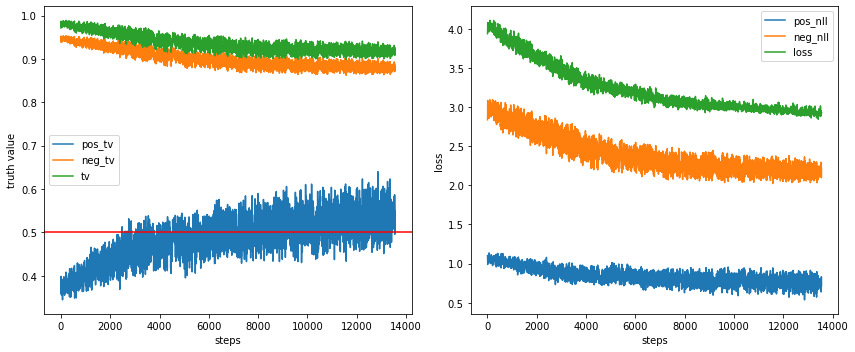

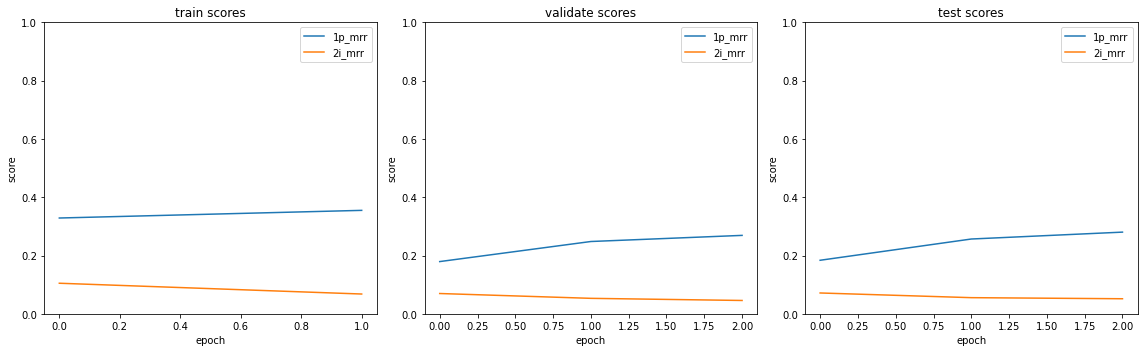

In [18]:
plot_train_lines()
plot_evaluation()
